# Solutions · 01 · Numbers, errors and reporting results

Worked solutions to the exercises of [notebook 01](../notebooks/01_errors_and_uncertainty.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import reporting
def efficiency(Q, H, P, rho=998.0, g=9.81):
    return rho * g * Q * H / P
values = {"Q": 0.0125, "H": 32.0, "P": 5200.0}
unc = {"Q": 0.0002, "H": 0.4, "P": 60.0}

## Exercise 1

Compute $\ln(1+x)$ for $x = 10^{-12}$ directly and with `np.log1p`. Explain the difference.

In [2]:
x = 1e-12
direct, stable = np.log(1 + x), np.log1p(x)
print(f"log(1 + x) = {direct:.16e}\nlog1p(x)   = {stable:.16e}\nrelative error of the direct form: {abs(direct/stable - 1):.1e}")
print(f"spacing of doubles near 1: {np.spacing(1.0):.2e}")

log(1 + x) = 1.0000889005818410e-12
log1p(x)   = 9.9999999999949996e-13
relative error of the direct form: 8.9e-05
spacing of doubles near 1: 2.22e-16


$1 + 10^{-12}$ must be rounded to the nearest double, and near 1 the doubles are $2.2\times10^{-16}$ apart. The
rounding changes the *small part* $x$ by up to about $10^{-4}$ of itself, and the logarithm faithfully returns
that wrong value. `np.log1p` computes $\ln(1 + x)$ without ever forming $1 + x$. The same problem - and the
same kind of cure (`np.expm1`, `np.hypot`) - appears whenever a small quantity is added to a large one.

## Exercise 2

A heat exchanger duty is $\dot{Q} = \dot{m} c_p (T_{out} - T_{in})$ with $T_{in} = 20.0 \pm 0.2$ °C and
   $T_{out} = 24.0 \pm 0.2$ °C. Why is the relative uncertainty of $\dot{Q}$ so large? Redesign the
   measurement to reduce it.

In [3]:
dT, u_dT = 24.0 - 20.0, np.hypot(0.2, 0.2)
print(f"temperature rise {dT:.1f} ± {u_dT:.2f} K  ->  relative uncertainty {u_dT/dT:.1%}")
for u_diff in (0.05, 0.02):
    print(f"with a differential sensor measuring the rise directly (±{u_diff} K): {u_diff/dT:.2%}")
print(f"or double the temperature rise (halve the flow): {np.hypot(0.2, 0.2)/8:.1%}")

temperature rise 4.0 ± 0.28 K  ->  relative uncertainty 7.1%
with a differential sensor measuring the rise directly (±0.05 K): 1.25%
with a differential sensor measuring the rise directly (±0.02 K): 0.50%
or double the temperature rise (halve the flow): 3.5%


The duty depends on the **difference** of two similar temperatures. Their absolute uncertainties add (in
quadrature), while the difference itself is small, so the relative uncertainty is large - the same
cancellation as in the quadratic-formula example. Remedies: measure the difference directly (a
differential thermocouple or thermopile, whose calibration errors largely cancel), or design the test
for a larger temperature rise.

## Exercise 3

Use Monte Carlo to find the uncertainty of $\eta$ if the power meter uncertainty were 20 %. Is the
   distribution still symmetric?

linear propagation: 0.753 ± 0.151
Monte Carlo: mean 0.788, SD 0.189, skewness 1.80
95 % interval [0.540, 1.242]: 0.214 below the median, 0.488 above


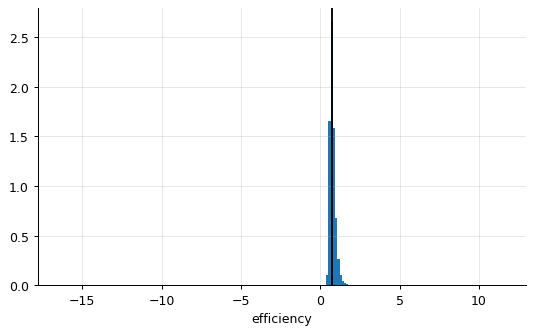

In [4]:
from scipy import stats
rng = np.random.default_rng(3)
N = 1_000_000
eta = efficiency(rng.normal(values["Q"], unc["Q"], N), rng.normal(values["H"], unc["H"], N),
                 rng.normal(values["P"], 0.20 * values["P"], N))
lin_value, lin_u, _ = reporting.propagate(efficiency, values, {**unc, "P": 0.20 * values["P"]})
lo, med, hi = np.percentile(eta, [2.5, 50, 97.5])
print(f"linear propagation: {lin_value:.3f} ± {lin_u:.3f}")
print(f"Monte Carlo: mean {eta.mean():.3f}, SD {eta.std():.3f}, skewness {stats.skew(eta):.2f}")
print(f"95 % interval [{lo:.3f}, {hi:.3f}]: {med - lo:.3f} below the median, {hi - med:.3f} above")
plt.hist(eta, bins=200, density=True); plt.axvline(lin_value, color="k"); plt.xlabel("efficiency"); plt.show()

The distribution is clearly **skewed to the right**, and its mean lies above the nominal value. The
efficiency depends on $1/P$, a curved function: low power readings raise $\eta$ more than high readings
lower it. With 20 % input uncertainty the linear formula - which assumes a straight-line dependence -
no longer describes the shape, and even the standard deviation differs. Report the Monte Carlo interval.

## Exercise 4

**Implement it yourself:** extend `propagate_by_hand` to correlated inputs, $u^2 = \sum_i\sum_j c_i u_i\, R_{ij}\, c_j u_j$ with a correlation matrix $R$. How does $u(\eta)$ change if the errors in $Q$ and $H$ have correlation $+0.5$? And $-0.5$?

In [5]:
def propagate_correlated(func, values, unc, R):
    names = list(values)
    cu = np.empty(len(names))
    for i, name in enumerate(names):
        h = 1e-6 * abs(values[name])
        up, down = {**values, name: values[name] + h}, {**values, name: values[name] - h}
        cu[i] = (func(**up) - func(**down)) / (2*h) * unc[name]
    return func(**values), float(np.sqrt(cu @ np.asarray(R) @ cu))

for rho_QH in (0.0, 0.5, -0.5):
    R = np.eye(3); R[0, 1] = R[1, 0] = rho_QH
    eta0, u = propagate_correlated(efficiency, values, unc, R)
    print(f"correlation(Q, H) = {rho_QH:+.1f}: u(eta) = {u:.4f}")

correlation(Q, H) = +0.0: u(eta) = 0.0176
correlation(Q, H) = +0.5: u(eta) = 0.0206
correlation(Q, H) = -0.5: u(eta) = 0.0140


$\eta$ increases with both $Q$ and $H$, so their sensitivity coefficients have the same sign. A positive
correlation (e.g. both read by instruments sharing a drifting reference) makes their errors reinforce
each other and increases $u(\eta)$; a negative correlation partly cancels them. Ignoring correlation can
therefore understate *or* overstate an uncertainty.